# Threshold Optimization

This notebook investigates how different decision thresholds affect the performance of the Random Forest classifier.

While the previous model comparison used the standard threshold of 0.5, the objective of this notebook is to analyze the trade-off between Precision and Recall for different business requirements.

## Why Thresholds Matter

Most classifiers do not directly predict classes.

Instead, they predict probabilities.

A threshold is used to convert probabilities into class predictions.

Default threshold:

0.5

Business requirements may justify different threshold values.

In [1]:
import pandas as pd

df = pd.read_csv("random_forest_predictions.csv")
y_true = df["y_true"]
y_prob = df["y_prob"]

print(df.head())

   y_true  y_prob
0       0     0.0
1       0     0.0
2       0     0.0
3       0     0.0
4       0     0.0


In [2]:
print(df.shape)
print(df.info())

(56746, 2)
<class 'pandas.DataFrame'>
RangeIndex: 56746 entries, 0 to 56745
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y_true  56746 non-null  int64  
 1   y_prob  56746 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 886.8 KB
None


Thresholds: 78


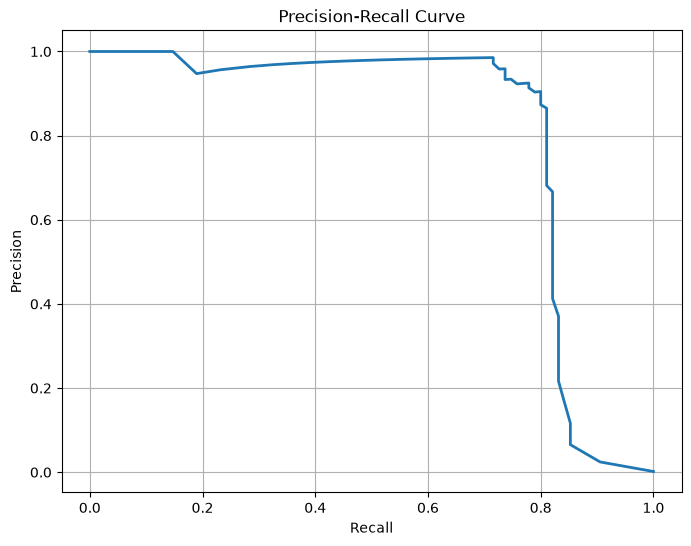

In [3]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, threshold = precision_recall_curve(y_true, y_prob)
print("Thresholds:", len(threshold))

plt.figure(figsize = (8,6))
plt.plot(recall, precision, linewidth = 2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

- Für Recall von ungefähr 0.0 bis 0.7 bleibt die Precision nahezu bei 1.0
- Zwischen etwa 0.7 und 0.8 Recall beginnt die Precision leicht zu fallen
- Danach kommt ein deutlicher Knick.
- Um Recall in Richtung 1.0 zu treiben, bricht die Precision massiv ein

In [5]:
from sklearn.metrics import(precision_score, recall_score, f1_score, confusion_matrix)

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for threshold in thresholds_to_test:
    y_pred = (y_prob >= threshold).astype(int)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    results.append([threshold, precision, recall, f1, fp, fn])

results_df = pd.DataFrame(results, columns =["Threshold", "Precision", "Recall", "F1", "False Positive", "False Negative"])
results_df

,Threshold,Precision,Recall,F1,False Positive,False Negative
0,0.1,0.733333,0.810526,0.770000,28,18
1,0.2,0.855556,0.810526,0.832432,13,18
2,0.3,0.913580,0.778947,0.840909,7,21
3,0.4,0.933333,0.736842,0.823529,5,25
4,0.5,0.958333,0.726316,0.826347,3,26
5,0.6,0.958333,0.726316,0.826347,3,26
6,0.7,0.985075,0.694737,0.814815,1,29
7,0.8,0.984127,0.652632,0.784810,1,33
8,0.9,0.980769,0.536842,0.693878,1,44


# Threshold Optimization

In the previous notebooks, all models were evaluated using the default classification threshold of 0.5.

While this approach allows a fair comparison between models, the optimal threshold depends on the specific business objective.

In fraud detection, there is a trade-off between:

- Precision: How many detected fraud cases are actually fraudulent?
- Recall: How many fraudulent transactions are successfully detected?

A lower threshold typically increases Recall but may generate more false alarms (False Positives).

A higher threshold typically reduces false alarms but may miss more fraudulent transactions (False Negatives).

The objective of this notebook is to analyze how different threshold values affect the performance of the Random Forest classifier and to identify threshold settings that may better align with business requirements.

## Why Thresholds Matter

The Random Forest model predicts probabilities rather than class labels.

The default classification rule is:

Probability ≥ 0.5 → Fraud

Probability < 0.5 → Legitimate Transaction

However, there is no guarantee that 0.5 is the best threshold for fraud detection.

For example:

- A financial institution may prioritize Recall to detect as many fraud cases as possible.
- Another organization may prioritize Precision to minimize unnecessary investigations.

This notebook explores the impact of different thresholds on Precision, Recall, F1-Score and classification errors.

## Key Findings

The analysis shows that model performance depends not only on the machine learning algorithm but also on the selected decision threshold.

Key observations:

- The default threshold of 0.5 achieved the highest Precision (0.96) and generated only 3 False Positives.
- A threshold of 0.3 achieved the highest F1-Score (0.84) and detected more fraudulent transactions.
- Lower thresholds increase Recall but also increase the number of False Positives.
- Higher thresholds reduce False Positives but miss more fraud cases.

For this dataset, the optimal threshold depends on the business objective:

- If minimizing false alarms is the primary goal, a threshold close to 0.5 is appropriate.
- If detecting as many fraud cases as possible is more important, a lower threshold such as 0.3 may be preferable.

This experiment demonstrates that threshold selection can be as important as model selection itself.